In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import RandomOverSampler
from collections import Counter

In [2]:
data = pd.read_csv('train.csv')
data.head()

,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
0,0.000000,757.00,6.00,64.00,23.671858,23.671858,0.0,0.0,0.0,0.0,...,538.470740,944.00,8.334058e+07,9.5,41.845546,761.456760,305219.322301,0.95,141.55,DDoS-ACK_Fragmentation
1,0.000000,54.00,6.00,64.00,2.393046,2.393046,0.0,0.0,1.0,0.0,...,0.000000,54.00,8.309327e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DDoS-SYN_Flood
2,0.033982,56.78,6.11,64.64,1.192715,1.192715,0.0,0.0,0.0,0.0,...,1.727526,54.29,8.333086e+07,9.5,10.462813,2.445286,16.853118,0.19,141.55,DDoS-PSHACK_Flood
3,0.000000,0.00,47.00,64.00,9.841972,9.841972,0.0,0.0,0.0,0.0,...,0.000000,592.00,8.370278e+07,9.5,34.409301,0.000000,0.000000,0.00,141.55,Mirai-greeth_flood
4,3.944828,108.00,6.00,64.00,0.506993,0.506993,0.0,0.0,1.0,0.0,...,0.000000,54.00,8.297270e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DoS-SYN_Flood


In [3]:
data['label'].value_counts() 

label
DDoS-ICMP_Flood            848088
DDoS-UDP_Flood             637558
DDoS-TCP_Flood             528499
DDoS-PSHACK_Flood          481254
DDoS-SYN_Flood             478653
DDoS-RSTFINFlood           475441
DDoS-SynonymousIP_Flood    422083
DoS-UDP_Flood              390422
DoS-TCP_Flood              314174
DoS-SYN_Flood              237573
BenignTraffic              129538
Mirai-greeth_flood         116133
Mirai-udpplain             104814
Mirai-greip_flood           88821
DDoS-ICMP_Fragmentation     53046
MITM-ArpSpoofing            36316
DDoS-UDP_Fragmentation      34169
DDoS-ACK_Fragmentation      33581
DNS_Spoofing                21214
Recon-HostDiscovery         15737
Recon-OSScan                11587
Recon-PortScan               9648
DoS-HTTP_Flood               8487
VulnerabilityScan            4396
DDoS-HTTP_Flood              3371
DDoS-SlowLoris               2757
DictionaryBruteForce         1541
BrowserHijacking              665
CommandInjection              620
SqlInjec

In [4]:
data.describe()

,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,AVG,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight
count,5.491971e+06,5.491971e+06,5.491971e+06,5.491971e+06,5.491971e+06,5.491971e+06,5.491971e+06,5.491971e+06,5.491971e+06,5.491971e+06,...,5.491971e+06,5.491971e+06,5.491971e+06,5.491971e+06,5.491971e+06,5.491971e+06,5.491971e+06,5.491971e+06,5.491971e+06,5.491971e+06
mean,5.657345e+00,7.687147e+04,9.066457e+00,6.636141e+01,9.049942e+03,9.049942e+03,3.229612e-06,8.650082e-02,2.071142e-01,9.042418e-02,...,1.247361e+02,3.341244e+01,1.247348e+02,8.319404e+07,9.499002e+00,1.312450e+01,4.721960e+01,3.076685e+04,9.657527e-02,1.415261e+02
std,2.749157e+02,4.615005e+05,8.943837e+00,1.406518e+01,9.986400e+04,9.986400e+04,1.848825e-03,2.811022e-01,4.052381e-01,2.867885e-01,...,2.411282e+02,1.604832e+02,2.416016e+02,1.706512e+07,8.201925e-01,8.632303e+00,2.269779e+02,3.208097e+05,2.332437e-01,2.109219e+01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,4.200000e+01,0.000000e+00,4.200000e+01,0.000000e+00,1.000000e+00,9.165151e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
25%,0.000000e+00,5.400000e+01,6.000000e+00,6.400000e+01,2.093860e+00,2.093860e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,5.000000e+01,0.000000e+00,5.000000e+01,8.307157e+07,9.500000e+00,1.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,1.415500e+02
50%,0.000000e+00,5.400000e+01,6.000000e+00,6.400000e+01,1.578598e+01,1.578598e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,5.400000e+01,0.000000e+00,5.400000e+01,8.312452e+07,9.500000e+00,1.039230e+01,0.000000e+00,0.000000e+00,0.000000e+00,1.415500e+02
75%,1.050286e-01,3.001300e+02,1.444000e+01,6.400000e+01,1.178755e+02,1.178755e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,5.405011e+01,3.719096e-01,5.406000e+01,8.334391e+07,9.500000e+00,1.039671e+01,5.059213e-01,1.344216e+00,8.000000e-02,1.415500e+02
max,9.943576e+04,9.890105e+06,4.700000e+01,2.550000e+02,8.388608e+06,8.388608e+06,2.679210e+00,1.000000e+00,1.000000e+00,1.000000e+00,...,1.160047e+04,9.302373e+03,1.309800e+04,1.676394e+08,1.500000e+01,1.453904e+02,1.315554e+04,9.670837e+07,1.000000e+00,2.446000e+02


Split train and test data

In [5]:
X = data.drop(columns=['label'])
y = data['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Use Standard Scaler

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train_scaled.shape, X_test_scaled.shape

((4393576, 46), (1098395, 46))

Encode the training data

In [7]:
encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)

Compute Class weights

In [8]:
classes = np.unique(y_train_encoded)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train_encoded)
class_weight_dict = dict(zip(classes, class_weights))

Use SMOTE

In [9]:
print("Original training class distribution:", Counter(y_train_encoded))

Original training class distribution: Counter({np.int64(6): 678500, np.int64(14): 510095, np.int64(13): 423457, np.int64(8): 384950, np.int64(10): 382681, np.int64(9): 380113, np.int64(12): 337846, np.int64(21): 312349, np.int64(20): 251036, np.int64(19): 190020, np.int64(1): 103517, np.int64(23): 93028, np.int64(25): 83928, np.int64(24): 71019, np.int64(7): 42431, np.int64(22): 28978, np.int64(15): 27382, np.int64(4): 26853, np.int64(16): 16992, np.int64(26): 12589, np.int64(27): 9221, np.int64(29): 7738, np.int64(18): 6852, np.int64(32): 3492, np.int64(5): 2671, np.int64(11): 2203, np.int64(17): 1199, np.int64(2): 525, np.int64(3): 505, np.int64(30): 470, np.int64(33): 322, np.int64(0): 299, np.int64(28): 198, np.int64(31): 117})


In [10]:
target_counts = {}
for cls, count in Counter(y_train_encoded).items():
    if count < 8000:
        target_counts[cls] = 8000
smote = SMOTE(sampling_strategy=target_counts, random_state=42, k_neighbors=3)  # k_neighbors can be tuned
X_res, y_res = smote.fit_resample(X_train_scaled, y_train_encoded)

c:\Users\ahmed\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\ahmed\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\ahmed\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\ahmed\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^

Model Training

In [11]:
model = Sequential([
    Dense(136, activation='relu', input_shape=(X_res.shape[1],)),
    Dense(68, activation='relu'),
    Dense(34, activation='softmax')
])

c:\Users\ahmed\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 136)            │         6,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 68)             │         9,316 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 34)             │         2,346 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,054 (70.52 KB)

 Trainable params: 18,054 (70.52 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model.compile(optimizer='Adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [14]:
history = model.fit(X_res, y_res, epochs=3, validation_split=0.2, class_weight=class_weight_dict)

Epoch 1/3
111775/111775 ━━━━━━━━━━━━━━━━━━━━ 175s 2ms/step - accuracy: 0.7854 - loss: 1.8888 - val_accuracy: 0.7809 - val_loss: 0.7978
Epoch 2/3
111775/111775 ━━━━━━━━━━━━━━━━━━━━ 187s 2ms/step - accuracy: 0.8347 - loss: 2.1301 - val_accuracy: 0.7950 - val_loss: 0.7527
Epoch 3/3
111775/111775 ━━━━━━━━━━━━━━━━━━━━ 191s 2ms/step - accuracy: 0.8414 - loss: 2.5210 - val_accuracy: 0.8018 - val_loss: 0.9755


In [15]:

y_log = model.predict(X_test_scaled)
y_pred = np.argmax(y_log, axis=1)
y_pred_labels = encoder.inverse_transform(y_pred)
print(classification_report(y_test, y_pred_labels))

34325/34325 ━━━━━━━━━━━━━━━━━━━━ 28s 803us/step


c:\Users\ahmed\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ahmed\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                         precision    recall  f1-score   support

       Backdoor_Malware       0.00      0.00      0.00        93
          BenignTraffic       0.77      0.69      0.73     26021
       BrowserHijacking       0.00      0.00      0.00       140
       CommandInjection       0.23      0.13      0.17       115
 DDoS-ACK_Fragmentation       0.92      0.98      0.95      6728
        DDoS-HTTP_Flood       0.33      0.87      0.47       700
        DDoS-ICMP_Flood       1.00      1.00      1.00    169588
DDoS-ICMP_Fragmentation       0.99      0.97      0.98     10615
      DDoS-PSHACK_Flood       1.00      1.00      1.00     96304
       DDoS-RSTFINFlood       1.00      1.00      1.00     95328
         DDoS-SYN_Flood       0.78      0.89      0.83     95972
         DDoS-SlowLoris       0.40      0.58      0.48       554
DDoS-SynonymousIP_Flood       0.90      0.93      0.91     84237
         DDoS-TCP_Flood       0.76      0.93      0.84    105042
         DDoS-UDP_Flood 

c:\Users\ahmed\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [16]:
history.history

{'accuracy': [0.7853999137878418, 0.8347080945968628, 0.8413610458374023],
 'loss': [1.8888288736343384, 2.1300854682922363, 2.521019458770752],
 'val_accuracy': [0.7809420228004456, 0.7950183153152466, 0.8018456697463989],
 'val_loss': [0.797762393951416, 0.7526720762252808, 0.9754527807235718]}

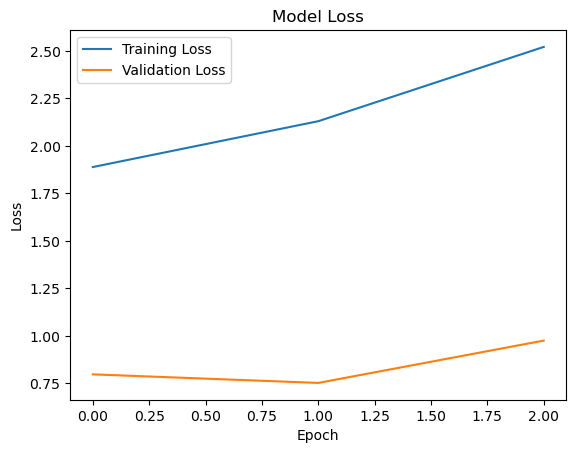

In [17]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

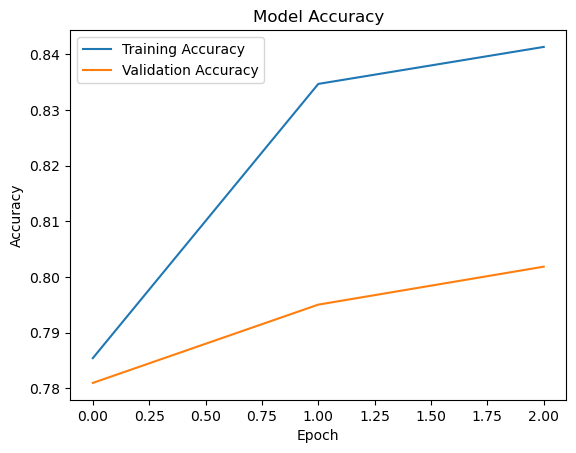

In [18]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [19]:
test = pd.read_csv('test.csv')
X_final = test.drop(columns=['label'])
y_final = test['label']
X_final_scaled = scaler.transform(X_final)
y_final_log = model.predict(X_final_scaled)
y_final_pred = np.argmax(y_final_log, axis=1)
y_final_pred_labels = encoder.inverse_transform(y_final_pred)
print(classification_report(y_final, y_final_pred_labels))

36777/36777 ━━━━━━━━━━━━━━━━━━━━ 28s 766us/step


c:\Users\ahmed\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ahmed\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                         precision    recall  f1-score   support

       Backdoor_Malware       0.00      0.00      0.00        89
          BenignTraffic       0.77      0.69      0.73     27709
       BrowserHijacking       0.01      0.03      0.02       134
       CommandInjection       0.16      0.08      0.11       119
 DDoS-ACK_Fragmentation       0.91      0.98      0.95      7292
        DDoS-HTTP_Flood       0.32      0.86      0.46       709
        DDoS-ICMP_Flood       1.00      1.00      1.00    180447
DDoS-ICMP_Fragmentation       0.99      0.97      0.98     11402
      DDoS-PSHACK_Flood       1.00      1.00      1.00    103326
       DDoS-RSTFINFlood       1.00      1.00      1.00    101819
         DDoS-SYN_Flood       0.78      0.89      0.83    102208
         DDoS-SlowLoris       0.41      0.56      0.47       622
DDoS-SynonymousIP_Flood       0.89      0.93      0.91     90480
         DDoS-TCP_Flood       0.76      0.93      0.84    113735
         DDoS-UDP_Flood 

c:\Users\ahmed\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [20]:
validation = pd.read_csv('validation.csv')
X_val = validation.drop(columns=['label'])
y_val = validation['label']
X_val_scaled = scaler.transform(X_val)
y_val_log = model.predict(X_val_scaled)
y_val_pred = np.argmax(y_val_log, axis=1)
y_val_pred_labels = encoder.inverse_transform(y_val_pred)
print(classification_report(y_val, y_val_pred_labels))

36777/36777 ━━━━━━━━━━━━━━━━━━━━ 23s 614us/step


c:\Users\ahmed\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\ahmed\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                         precision    recall  f1-score   support

       Backdoor_Malware       0.00      0.00      0.00        93
          BenignTraffic       0.77      0.69      0.73     27519
       BrowserHijacking       0.02      0.05      0.03       158
       CommandInjection       0.19      0.11      0.14       132
 DDoS-ACK_Fragmentation       0.92      0.98      0.95      7194
        DDoS-HTTP_Flood       0.32      0.84      0.47       706
        DDoS-ICMP_Flood       1.00      1.00      1.00    182011
DDoS-ICMP_Fragmentation       0.99      0.97      0.98     11430
      DDoS-PSHACK_Flood       1.00      1.00      1.00    102985
       DDoS-RSTFINFlood       1.00      1.00      1.00    101563
         DDoS-SYN_Flood       0.78      0.89      0.83    102644
         DDoS-SlowLoris       0.42      0.56      0.48       620
DDoS-SynonymousIP_Flood       0.90      0.93      0.92     90795
         DDoS-TCP_Flood       0.76      0.93      0.84    113888
         DDoS-UDP_Flood 

c:\Users\ahmed\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
